# Query Database

Author: Matteo Torres

### Import Libraries

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
from pyfonts import load_google_font

# load google font
Saira = load_google_font("Saira")

### Connect to Database

In [2]:
kanto_database = duckdb.connect(database = "kanto_database.duckdb")

### Query Database

Q3. What is the height distribution of the top five tallest Pokémon types in the Kanto region, and how does Ash Ketchum's height compare to these Pokémon?

In [3]:
# query boxplot statistics for the top five tallest pokémon by their primary type
q3_query = kanto_database.execute("""SELECT type_1, MIN(height_m) AS min_height,
                                  quantile_cont(height_m, 0.25) AS q1_height,
                                  quantile_cont(height_m, 0.5) AS med_height,
                                  quantile_cont(height_m, 0.75) AS q3_height,
                                  MAX(height_m) AS max_height
                                  FROM measurements
                                  JOIN base_stats
                                        ON measurements.national_no = base_stats.national_no
                                  GROUP BY type_1
                                  ORDER BY max_height DESC
                                  LIMIT 5;""").fetchdf()

# print df results
q3_query

,type_1,min_height,q1_height,med_height,q3_height,max_height
0,Rock,0.4,0.500,1.00,1.400,8.8
1,Water,0.3,0.800,1.10,1.525,6.5
2,Dragon,1.8,2.000,2.20,3.100,4.0
3,Poison,0.4,0.800,1.05,1.375,3.5
4,Normal,0.3,0.475,1.00,1.325,2.2


In [4]:
# convert df to dictionary for plotting
q3_data = []
for _, row in q3_query.iterrows():
    q3_data.append({
        "label": row["type_1"],
        "whislo": row["min_height"],
        "q1": row["q1_height"],
        "med": row["med_height"],
        "q3": row["q3_height"],
        "whishi": row["max_height"]
    })

# print dictionary preview
q3_data[0]

{'label': 'Rock',
 'whislo': 0.4000000059604645,
 'q1': 0.5,
 'med': 1.0,
 'q3': 1.399999976158142,
 'whishi': 8.800000190734863}

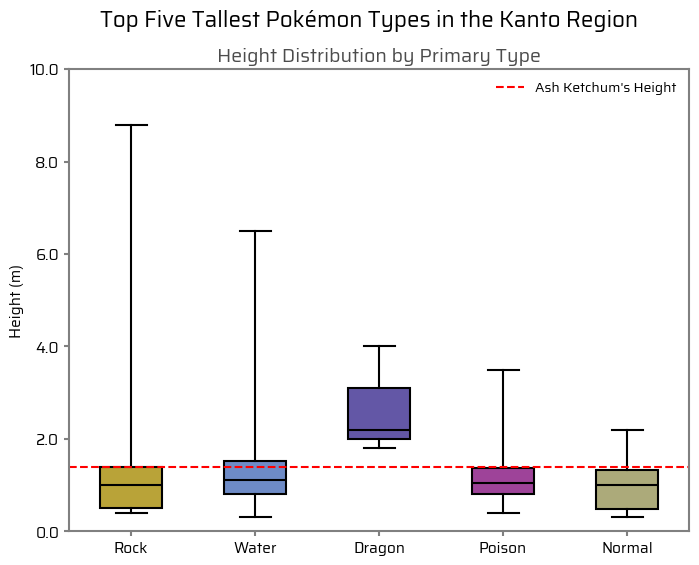

In [5]:
# create plot frame
fig, ax = plt.subplots(figsize = (8, 6))

# boxplot
boxplot = ax.bxp(q3_data,
                 showfliers = False,
                 medianprops = dict(color = "black", linewidth = 1.5),
                 boxprops = dict(linewidth = 1.5),
                 whiskerprops = dict(linewidth = 1.5),
                 capprops = dict(linewidth = 1.5),
                 patch_artist = True)

# define boxplot colors
colors = ["#b9a338", "#6e8bc6", "#6357a6", "#9e4399", "#acaa7a"]

# apply boxplot colors
for patch, color in zip(boxplot["boxes"], colors):
      patch.set_facecolor(color)

# add hline for Ash Ketchum's height
ax.axhline(y = 1.4,
           color = "red",
           linestyle = "--",
           linewidth = 1.5,
           label = "Ash Ketchum's Height")

# display legend
ax.legend(prop = Saira,
          edgecolor = "none")

# add y-axis title
ax.set_ylabel("Height (m)", font = Saira, fontsize = 11)

# format y-axis labels to show one decimal place (1 significant figure)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# adjust limits on y-axis
ax.set_ylim(0, 10)

# customize font family and size for both axis labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
       label.set_fontproperties(Saira)
       label.set_fontsize(11)

# customize line width and color of plot panel
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("grey")

# customize line width and color of axis ticks
ax.tick_params(width = 1.5,
               color = "grey")

# add title
fig.suptitle("Top Five Tallest Pokémon Types in the Kanto Region", font = Saira, fontsize = 16, fontweight = "bold")

# add subtitle
ax.set_title("Height Distribution by Primary Type", font = Saira, fontsize = 14, alpha = 0.7)

# save plot to folder
plt.savefig("images/plots/p3.png", dpi = 300, bbox_inches = "tight")

# display plot
plt.show()

Q4. Which Pokémon are the heaviest in the Kanto region, and what are their primary types?

In [6]:
q4_query = kanto_database.execute("""SELECT measurements.pokemon, type_1, weight_kg
                       FROM measurements
                       JOIN base_stats
                            ON measurements.national_no = base_stats.national_no
                       ORDER BY weight_kg DESC
                       LIMIT 5;""").fetchdf()

q4_query

,pokemon,type_1,weight_kg
0,Snorlax,Normal,460.0
1,Golem,Rock,300.0
2,Gyarados,Water,235.0
3,Lapras,Water,220.0
4,Onix,Rock,210.0


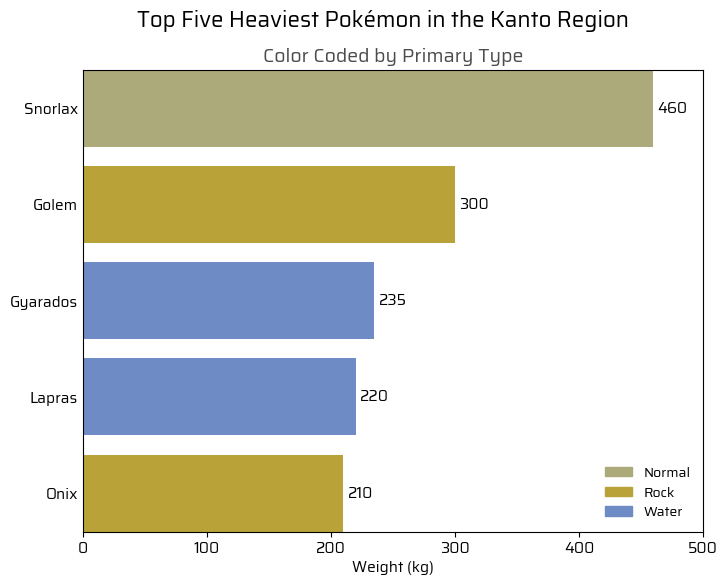

In [7]:
# create plot frame
fig, ax = plt.subplots(figsize = (8, 6))

# define barplot colors
colors = ["#b9a338", "#6e8bc6", "#6e8bc6", "#b9a338", "#acaa7a"]

# barplot
ax.barh(y = q4_query.sort_values(by = "weight_kg", ascending = True)["pokemon"],
        width = q4_query.sort_values(by = "weight_kg", ascending = True)["weight_kg"],
        color = colors)

# remove margins
ax.margins(y = 0)

# remove y-axis tick marks
ax.tick_params(axis = "y", length = 0)

# adjust limits on x-axis
ax.set_xlim(0, 500)

# add x-axis title 
ax.set_xlabel("Weight (kg)", font = Saira, fontsize = 11)

# customize font family and size for both axis labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
       label.set_fontproperties(Saira)
       label.set_fontsize(11)

# add labels
for container in ax.containers:
    ax.bar_label(container,
                 label_type = "edge",
                 padding = 3,
                 fontsize = 11,
                 font = Saira)

# create custom legend
legend_patches = [
    mpatches.Patch(color = "#acaa7a", label = "Normal"),
    mpatches.Patch(color = "#b9a338", label = "Rock"),
    mpatches.Patch(color = "#6e8bc6", label = "Water")
]

# customize legend
ax.legend(handles = legend_patches,
          prop = Saira,
          edgecolor = "none")

# add title
fig.suptitle("Top Five Heaviest Pokémon in the Kanto Region", font = Saira, fontsize = 16, fontweight = "bold")

# add subtitle
ax.set_title("Color Coded by Primary Type", font = Saira, fontsize = 14, alpha = 0.7)

# save plot to folder
plt.savefig("images/plots/p4.png", dpi = 300, bbox_inches = "tight")

# display plot
plt.show()